Starting Grid Search. This may take a minute due to the massive feature space at higher degrees...


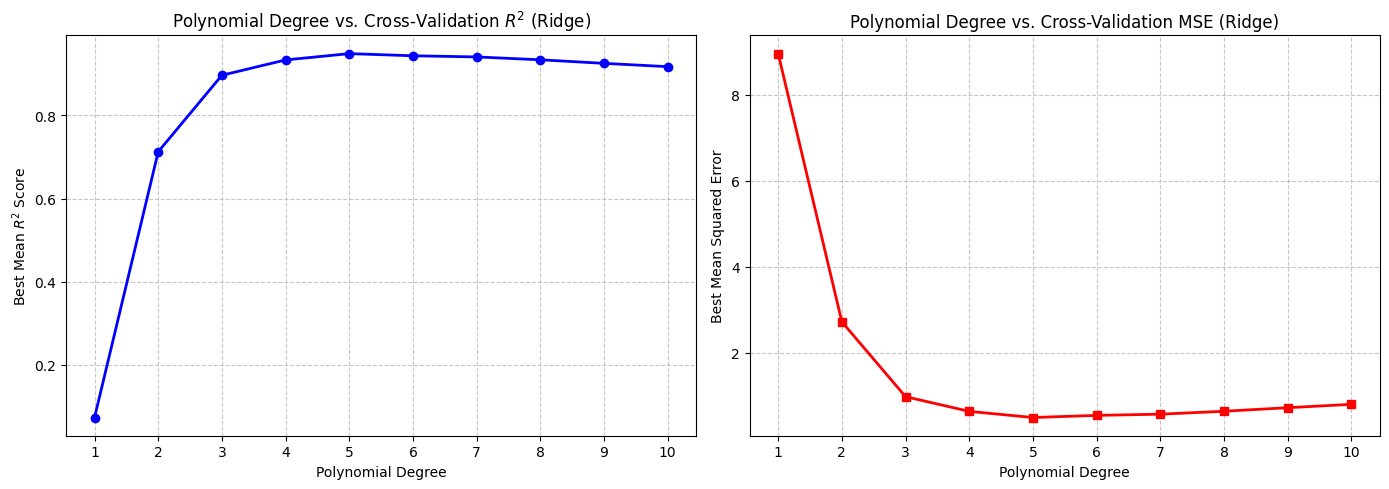

Optimal Polynomial Degree found: 5
Optimal Ridge Alpha found: 1.0
R-squared Score on Train/Test Split: 0.9510

Predictions successfully generated and saved to 'IMT2024078_predictions.csv'.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import warnings

# Suppress potential warnings from massive feature generation
warnings.filterwarnings("ignore")

# 1. Load the dataset
dataset_train = pd.read_csv('IMT2024078_train_var1(in).csv')
X = dataset_train.iloc[:, :-1].values
y = dataset_train.iloc[:, -1].values

# 2. Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. Create a modeling pipeline with Ridge Regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('ridge', Ridge())
])

# 4. Define the parameter grid
# Testing degrees 1 through 10 and three different regularization strengths
param_grid = {
    'poly__degree': list(range(1, 11)),
    'ridge__alpha': [0.1, 1.0, 10.0]
}

# 5. Set up GridSearchCV with MULTIPLE scoring metrics
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring={'r2': 'r2', 'neg_mse': 'neg_mean_squared_error'},
    refit='r2',
    n_jobs=-1
)

print("Starting Grid Search. This may take a minute due to the massive feature space at higher degrees...")
grid_search.fit(X_train, y_train)

# 6. Extract and format the results for plotting
results = grid_search.cv_results_
df_results = pd.DataFrame(results)

# Since we test multiple alphas per degree, we group by degree and take the best R2 score for each
best_per_degree = df_results.loc[df_results.groupby('param_poly__degree')['mean_test_r2'].idxmax()]

degrees = best_per_degree['param_poly__degree'].values.astype(int)
mean_r2 = best_per_degree['mean_test_r2'].values
mean_mse = -1 * best_per_degree['mean_test_neg_mse'].values

# --- Plotting Degree vs R2 and Degree vs MSE ---
plt.figure(figsize=(14, 5))

# Plot 1: Degree vs R2
plt.subplot(1, 2, 1)
plt.plot(degrees, mean_r2, marker='o', color='blue', linestyle='-', linewidth=2)
plt.title('Polynomial Degree vs. Cross-Validation $R^2$ (Ridge)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Best Mean $R^2$ Score')
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Degree vs MSE
plt.subplot(1, 2, 2)
plt.plot(degrees, mean_mse, marker='s', color='red', linestyle='-', linewidth=2)
plt.title('Polynomial Degree vs. Cross-Validation MSE (Ridge)')
plt.xlabel('Polynomial Degree')
plt.ylabel('Best Mean Squared Error')
plt.xticks(degrees)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# 7. Extract the best model and evaluate on the test set
best_model = grid_search.best_estimator_
best_degree = grid_search.best_params_['poly__degree']
best_alpha = grid_search.best_params_['ridge__alpha']

print(f"Optimal Polynomial Degree found: {best_degree}")
print(f"Optimal Ridge Alpha found: {best_alpha}")

y_pred = best_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred)
print(f"R-squared Score on Train/Test Split: {final_r2:.4f}\n")

# --- Test Set Predictions ---
dataset_unseen = pd.read_csv('IMT2024078_test_var1(in).csv')
X_unseen = dataset_unseen.values

# Predict using the trained best_model
final_predictions = best_model.predict(X_unseen)

# Save the predictions to a CSV file
output_df = pd.DataFrame({'Predicted_Net_Power_Score': final_predictions})
output_df.to_csv('IMT2024078_predictions.csv', index=False)
print("Predictions successfully generated and saved to 'IMT2024078_predictions.csv'.")

In [7]:
# Print the validation scores for each degree
print("\n--- Validation Scores per Degree (Ridge) ---")
for deg, r2, mse in zip(degrees, mean_r2, mean_mse):
    print(f"Degree {deg:2d} | Best CV R2: {r2:.6f} | Best CV MSE: {mse:.6f}")
print("--------------------------------------------\n")


--- Validation Scores per Degree (Ridge) ---
Degree  1 | Best CV R2: 0.073527 | Best CV MSE: 8.952540
Degree  2 | Best CV R2: 0.712498 | Best CV MSE: 2.718565
Degree  3 | Best CV R2: 0.896425 | Best CV MSE: 0.978122
Degree  4 | Best CV R2: 0.933252 | Best CV MSE: 0.636700
Degree  5 | Best CV R2: 0.948399 | Best CV MSE: 0.493238
Degree  6 | Best CV R2: 0.943241 | Best CV MSE: 0.543189
Degree  7 | Best CV R2: 0.940458 | Best CV MSE: 0.571086
Degree  8 | Best CV R2: 0.933567 | Best CV MSE: 0.639088
Degree  9 | Best CV R2: 0.925046 | Best CV MSE: 0.721397
Degree 10 | Best CV R2: 0.917073 | Best CV MSE: 0.800279
--------------------------------------------

